This notebook generates the plots used in figure X of the report. All relevant data is generated by other code in this repository

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Defining plotting functions

In [2]:
def create_pearsons_violin(results_df, y_col, title, file_title, figure_root = './figures', **kwargs):
    '''
    Taking a results df with two columns ['pearsons', 'dataset'] 
    Plots the pearsons values by dataset of origin as violin plots and saves figure with specified file_title at figure_root

    Parameters
    ---------------
    results_df : pandas dataframe
        dataframe containg the results to plot. Must contain a categorical column called dataset to serve as x axis categories
    y_col : string
        name of column in results df with statistic to make violin plot for 
    title : string
        title to display on plot
    file_title : string
        filename of saved figure
    figure_root : string
        path to directory in which to save the figure

    Returns
    --------------
    None
        Saves figure to desired location
    '''

    #store all plot formating arguments in dictionary - kwargs can then override
    plot_defaults = {'ylim':(-1, 1),
                     'palette':'viridis'}

    plot_kwargs = {**plot_defaults, **kwargs}

    #violin_plot_arguments = list(inspect.signature(sns.violinplot).parameters.keys())

    savepath = f'{figure_root}/{file_title}'

    fig, ax = plt.subplots(figsize = (10, 7))
    
    ax = sns.violinplot(data = results_df, x = 'dataset', y= y_col, hue = 'dataset', palette=plot_kwargs['palette'], inner = 'box')

    if y_col == 'pearsons':
        ax.set_ylabel('Pearsons R', fontsize = 15)
    elif y_col == 'spearmans':
        ax.set_ylabel('Spearmans Rank', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
   
    plt.ylim(plot_kwargs['ylim'])
    fig.suptitle(title, fontsize = 20)

    for i, dataset in enumerate(np.unique(results_df['dataset'])):
        vals = results_df.loc[results_df['dataset'] == dataset, 'PCC'].dropna()

        median = np.median(vals)
        mean   = np.mean(vals)
        q1     = np.percentile(vals, 25)
        q3     = np.percentile(vals, 75)

        stats_text = (
            f"Median: {median:.3f}\n"
            f"Mean: {mean:.3f}\n"
            f"IQR: [{q1:.3f}, {q3:.3f}]"
        )

        ax.text(
            i,                  
            0,             
            stats_text,
            ha='center',
            va='top',
            fontsize=10,
            family='monospace',
            bbox=dict(
                boxstyle='round,pad=0.4',
                facecolor='lightyellow',
                edgecolor='gray',
                alpha=0.8
            )
        )
    #plt.savefig(savepath, dpi = 300, bbox_inches = 'tight')

In [3]:
#define palette for train, test, male and female samples that will be used across the dataset
palette = {'Train': '#4b4ba3', 'Test' : '#248af0', 'Male': '#C1121F', 'Female': '#FDF1D7'}

## Genewise Pearsons Loss in Deep Learning Model across Train, Test, Male External, Female External

In [4]:
DATA_ROOT = '../data'

In [5]:
#load train and test loss function values generated during training
train_test_scores = pd.read_csv(f'{DATA_ROOT}/MF_external_results.csv', index_col = 0)

#transform loss into PCC and name column desired X labels of violin plot
train_test_scores['train_PCC'] = 1 - train_test_scores['train_loss']
train_test_scores['test_PCC'] = 1 - train_test_scores['test_loss']

In [ ]:
#load PCC from external male and female samples (do not need to transform these)
MF_scores = pd.read_csv(f'{DATA_ROOT}/female_male_PCC.csv', index_col = 0)

#get only TGs with better than 80% correlation in male and females
MF_scores[(MF_scores['female_PCC'] > 0.7) & (MF_scores['male_PCC'] > 0.7)]

,female_PCC,male_PCC
A2M,0.806213,0.729356
AAAS,0.910583,0.906642
AACS,0.834587,0.814923
AADAT,0.719707,0.702102
AAGAB,0.909897,0.936911
...,...,...
ZXDB,0.849122,0.889161
ZXDC,0.919298,0.897808
ZYG11B,0.806999,0.840889
ZZEF1,0.914712,0.910695


In [7]:
#create a plotting dataframe that will be melted for use with create_pearsons_violin, columns are named for X axis ticks
plot_frame = pd.DataFrame(index = MF_scores.index, columns = ['Train', 'Test', 'Female', 'Male'])
plot_frame['Train'] = train_test_scores['train_PCC']
plot_frame['Test'] = train_test_scores['test_PCC']
plot_frame['Female'] = MF_scores['female_PCC']
plot_frame['Male'] = MF_scores['male_PCC']

#melt df so compatible with plotting functions
plot_frame = plot_frame.melt()
plot_frame.columns = ['dataset', 'PCC']

In [8]:
plot_frame

,dataset,PCC
0,Train,0.822578
1,Train,0.850277
2,Train,0.816557
3,Train,0.914901
4,Train,0.899184
...,...,...
60791,Male,0.648618
60792,Male,0.840889
60793,Male,0.660019
60794,Male,0.910695


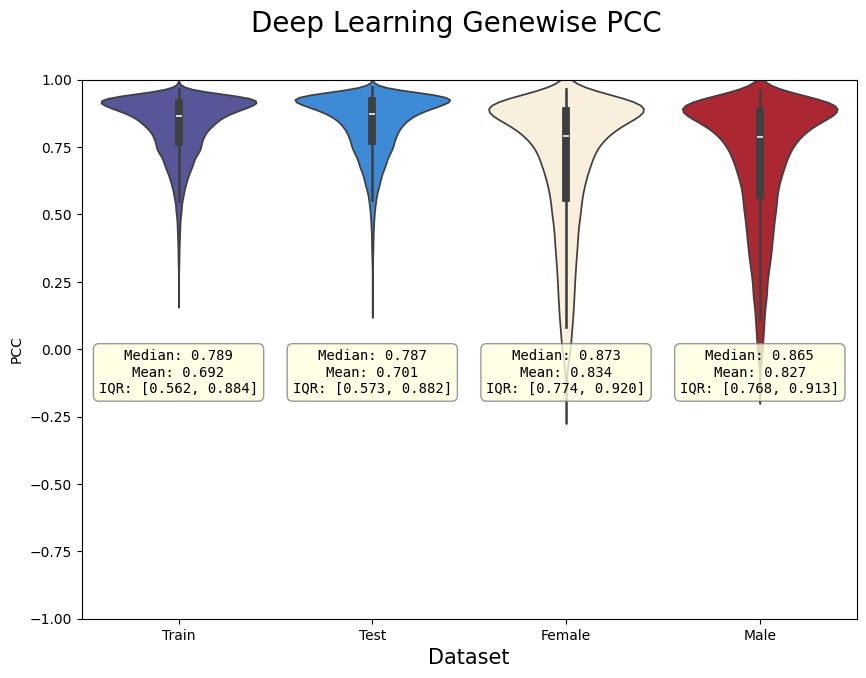

In [9]:
create_pearsons_violin(plot_frame, y_col = 'PCC', title = 'Deep Learning Genewise PCC', file_title = 'DL_genewise_PCC', palette = palette)